# Chapter 10 — Generative Models for Graphics: A Diffusion Primer
### Companion Colab notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/erprashu/neural-rendering-ch10-diffusion/blob/main/notebooks/ch10_diffusion_primer.ipynb)

This notebook contains **every runnable recipe from the chapter**, in the same order the
chapter introduces them, so you can run the code and see the visualizations while you read.

**How to use this notebook**
1. Click **Runtime → Change runtime type → T4 GPU** (top menu) before running anything —
   Parts 7–10 (Stable Diffusion / ControlNet) need a GPU to run in a reasonable time. Everything
   before that runs fine on CPU too.
2. Run cells **top to bottom** — later parts reuse variables and models defined earlier.
3. Each part starts with a short recap of the chapter section it demonstrates, so you can jump
   straight to the part you're currently reading.

**What's reduced from the book, and why:** three things run smaller than the chapter's numbers,
purely so the *whole notebook* finishes in a few minutes on free Colab hardware — the tiny image
DDPM (5 epochs instead of 20), the VAE, and Stable Diffusion's sampling loop (30 DDIM steps
instead of 50). Each is called out at the point it happens, with the chapter's number alongside
it wherever the chapter states one — the mechanism and the code are otherwise unchanged.

| Notebook part | Chapter section | What you'll see |
|---|---|---|
| 1 | §10.1.2 GANs | A real 2-player GAN trained live, samples + loss curves |
| 2 | §10.1.3 VAEs | VAE trained on MNIST: reconstructions, random samples, latent space |
| 3 | §10.2.1 / §10.2.3 | Forward noising process, linear vs. cosine noise schedules |
| 4 | §10.2.2 Recipe 10-1 | Diffusion on 2D points — the "watch structure emerge" demo |
| 5 | §10.2.6 Recipe 10-2 | A tiny image DDPM trained on Fashion-MNIST |
| 6 | §10.3 | The full `DDPMUNet` architecture (skips, FiLM, attention) |
| 7 | §10.4 Recipe 10-3 | Real Stable Diffusion, driven by hand, no black-box pipeline |
| 8 | §10.5.1 | Real classifier-free guidance scale sweep (Figure 10.7) |
| 9 | §10.5.2–3 Recipe 10-4 | Real ControlNet depth-conditioned generation (Figure 10.9) |
| 10 | §10.6.1–2 Recipe 10-5 | Real seamless tileable textures via `make_circular()` (Figure 10.10) |
| 11 | §10.6.3 | Mesh-texturing loop (conceptual sketch) |

*Note: Parts 7–10 use `stable-diffusion-v1-5/stable-diffusion-v1-5`, a public, ungated mirror of
Stable Diffusion 1.5 — no HuggingFace login or token is required.*

## Setup

Colab already has PyTorch, NumPy, Matplotlib, and scikit-learn preinstalled. We only need to add
`diffusers` (for Parts 7–10) and a couple of small support libraries.

In [1]:
%pip install -q --upgrade diffusers transformers accelerate safetensors
print("Done.")

Note: you may need to restart the kernel to use updated packages.
Done.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import math
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

# --- Reproducibility (chapter requirement #10: seed everything) ---
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cpu":
    print("No GPU detected -- Parts 1-6 will run fine, but Parts 7-10 (Stable Diffusion / "
          "ControlNet) will be slow. Runtime > Change runtime type > T4 GPU, then Runtime > "
          "Restart and run all.")

Using device: cuda


In [3]:
def show_image_grid(images, titles=None, cols=4, figsize=None, cmap="gray", suptitle=None):
    """Small shared helper used throughout this notebook to lay out a list of images
    (numpy arrays or PIL Images) in a grid, with optional per-image titles."""
    n = len(images)
    cols = max(1, min(cols, n))
    rows = math.ceil(n / cols)
    figsize = figsize or (3.1 * cols, 3.1 * rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes = axes.reshape(-1)
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(images[i], cmap=cmap)
            if titles is not None:
                ax.set_title(titles[i], fontsize=10)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

---
## Part 1 — GANs: generation as a two-player game (§10.1.2)

The chapter's GAN training loop is shown as a code fragment (`Generator()`, `Discriminator()`,
`dataloader` left undefined, since the point there is the *shape* of the training loop, not a
runnable model). Here it's wired up to an actual small 2D dataset — the same "two moons" shape
Recipe 10-1 uses later — so you can watch a real generator and discriminator train against each
other and see what a GAN's output distribution actually looks like.

In [4]:
from sklearn.datasets import make_moons
from torch.utils.data import DataLoader, TensorDataset

set_seed()

# Same "two moons" 2D dataset Recipe 10-1 uses later, so the GAN-vs-diffusion comparison
# is apples to apples: same data, same 2D output space.
X_gan, _ = make_moons(n_samples=2000, noise=0.05)
X_gan = torch.tensor((X_gan - X_gan.mean(0)) / X_gan.std(0), dtype=torch.float32)
gan_loader = DataLoader(TensorDataset(X_gan), batch_size=128, shuffle=True)

latent_dim = 8

class Generator(nn.Module):
    def __init__(self, latent_dim=latent_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

G = Generator()
D = Discriminator()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCELoss()   # ordinary binary cross-entropy: the loss for a 2-class (real/fake) problem

In [5]:
g_losses, d_losses = [], []
N_GAN_EPOCHS = 150

t0 = time.time()
for epoch in range(N_GAN_EPOCHS):
    for (real_images,) in gan_loader:
        batch_size = real_images.size(0)
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # --- Step 1: train the discriminator ---
        z = torch.randn(batch_size, latent_dim)
        fake_images = G(z).detach()          # detach: don't backprop into G here

        d_loss_real = bce(D(real_images), real_labels)
        d_loss_fake = bce(D(fake_images), fake_labels)
        d_loss = d_loss_real + d_loss_fake

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # --- Step 2: train the generator ---
        z = torch.randn(batch_size, latent_dim)
        fake_images = G(z)
        # G wants D to output 1 ("real") for its fakes:
        g_loss = bce(D(fake_images), real_labels)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

print(f"Trained {N_GAN_EPOCHS} epochs in {time.time() - t0:.1f}s "
      f"-- final G loss {g_losses[-1]:.3f}, D loss {d_losses[-1]:.3f}")

Trained 150 epochs in 5.9s -- final G loss 0.702, D loss 1.372


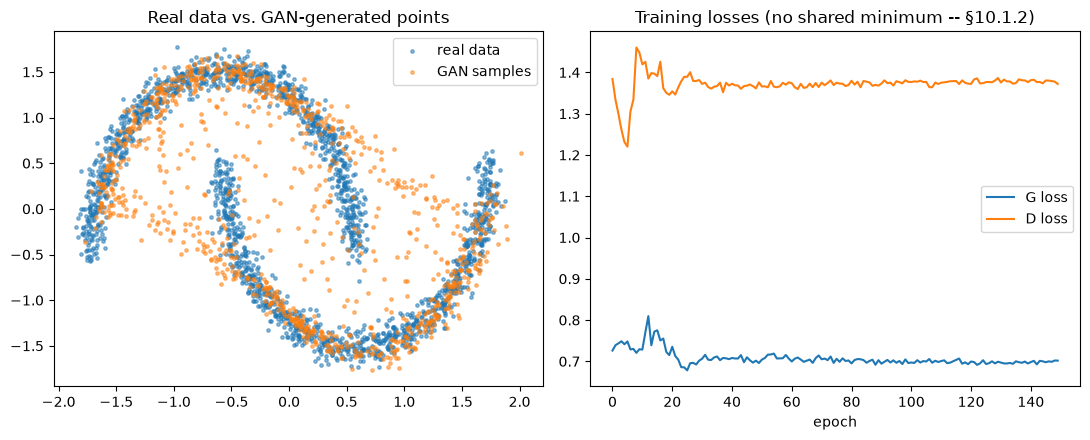

In [6]:
with torch.no_grad():
    gan_samples = G(torch.randn(1000, latent_dim)).numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X_gan[:, 0], X_gan[:, 1], s=6, alpha=0.5, label="real data")
axes[0].scatter(gan_samples[:, 0], gan_samples[:, 1], s=6, alpha=0.5, label="GAN samples")
axes[0].set_title("Real data vs. GAN-generated points")
axes[0].legend()
axes[1].plot(g_losses, label="G loss")
axes[1].plot(d_losses, label="D loss")
axes[1].set_title("Training losses (no shared minimum -- §10.1.2)")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

**What to look for:** the GAN samples should roughly cover the two crescent shapes, but usually
less evenly than the real data -- and unlike the diffusion loss you'll see in Part 4, the G/D
loss curves never settle to a shared minimum, because there isn't one (§10.1.2's "no single loss
both networks agree to minimize together"). Re-run the cell above a few times with different
seeds and watch how much more training-run-to-training-run variance there is compared to the
diffusion model in Part 4 -- a small, direct demonstration of §10.1.2's "training instability"
point.

---
## Part 2 — VAEs: the missing middle link (§10.1.3)

The chapter's `VAE` class and `vae_loss` function are already fully self-contained — reproduced
here verbatim — and trained on MNIST (downloaded automatically below). We'll look at three
things: reconstructions, brand-new digits sampled from random $\mathbf{z} \sim \mathcal{N}(0,\mathbf{I})$,
and a 2D projection of the latent space itself, to make §10.1.3's "densely and smoothly
populated" claim visible rather than just asserted.

In [7]:
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

set_seed()

mnist_transform = transforms.Compose([transforms.ToTensor()])  # keep [0, 1]: decoder ends in Sigmoid
mnist_train = MNIST(root="./data", train=True, download=True, transform=mnist_transform)
mnist_loader = DataLoader(mnist_train, batch_size=256, shuffle=True)
print(f"MNIST: {len(mnist_train)} training images")

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 438kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.55MB/s]

MNIST: 60000 training images


In [8]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)   # mu, log(sigma^2)

    def reparameterize(self, mu, logvar):
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)              # N(0, I); NOT a function of mu or sigma
        return mu + sigma * eps                     # z = mu + sigma * eps

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar


def vae_loss(x_hat, x, mu, logvar):
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum")
    # closed-form KL divergence between N(mu, sigma^2) and N(0, I):
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl


vae_model = VAE().to(DEVICE)
opt = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

In [9]:
# The chapter doesn't fix an epoch count here; 5 already gives recognizable reconstructions
# and keeps this cell to well under a minute on a Colab GPU (a couple of minutes on CPU).
N_VAE_EPOCHS = 5

t0 = time.time()
for epoch in range(N_VAE_EPOCHS):
    total_loss = 0.0
    for images, _ in mnist_loader:
        x = images.view(images.size(0), -1).to(DEVICE)
        x_hat, mu, logvar = vae_model(x)
        loss = vae_loss(x_hat, x, mu, logvar)

        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()

    print(f"epoch {epoch + 1}/{N_VAE_EPOCHS}  avg loss/sample: {total_loss / len(mnist_train):.2f}")

print(f"Trained in {time.time() - t0:.1f}s")

epoch 1/5  avg loss/sample: 202.37
epoch 2/5  avg loss/sample: 142.70
epoch 3/5  avg loss/sample: 128.29
epoch 4/5  avg loss/sample: 121.25
epoch 5/5  avg loss/sample: 117.41
Trained in 14.6s


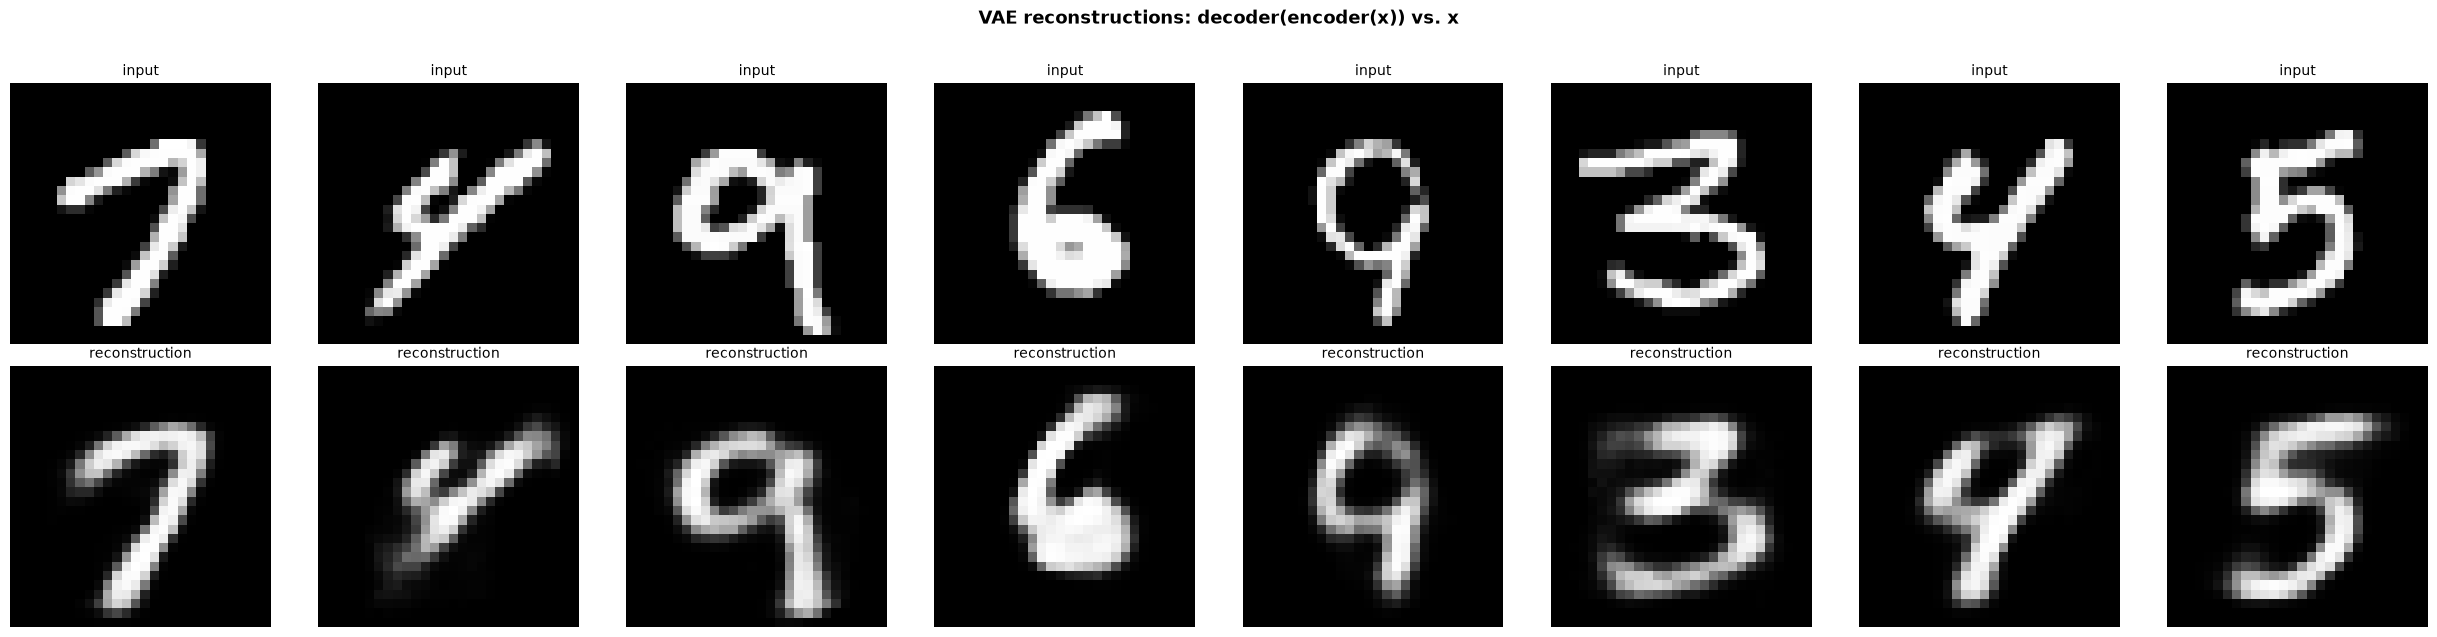

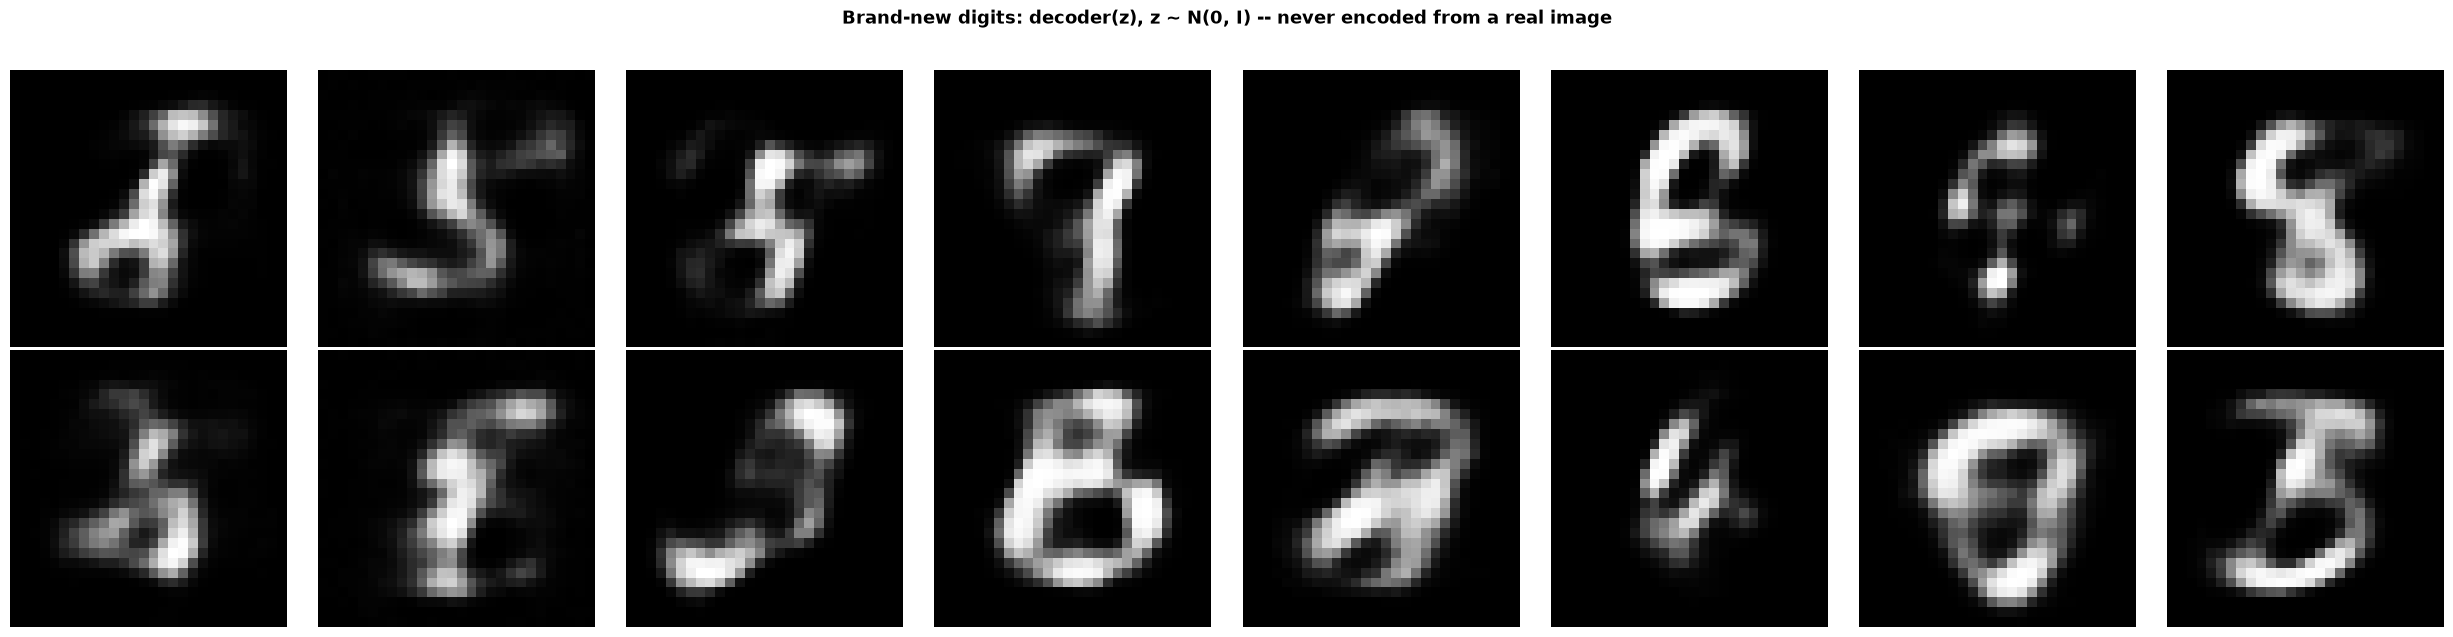

In [10]:
vae_model.eval()
with torch.no_grad():
    sample_batch, _ = next(iter(mnist_loader))
    x = sample_batch[:8].view(8, -1).to(DEVICE)
    x_hat, _, _ = vae_model(x)
    originals = x.view(8, 28, 28).cpu().numpy()
    recons = x_hat.view(8, 28, 28).cpu().numpy()

show_image_grid(list(originals) + list(recons),
                 titles=["input"] * 8 + ["reconstruction"] * 8, cols=8,
                 suptitle="VAE reconstructions: decoder(encoder(x)) vs. x")

with torch.no_grad():
    random_samples = vae_model.decoder(torch.randn(16, 32, device=DEVICE)).view(16, 28, 28).cpu().numpy()

show_image_grid(list(random_samples), cols=8,
                 suptitle="Brand-new digits: decoder(z), z ~ N(0, I) -- never encoded from a real image")

**Concept check (from the chapter):** is a *plain* autoencoder generative? Try it — set
`kl = 0 * kl` in `vae_loss` above (or retrain with `beta=0`), regenerate the "brand-new digits"
grid, and compare. Expect noisy, unrecognizable output: without the KL term pulling the latent
space toward a dense, zero-centered Gaussian, a random $\mathbf{z}$ lands in one of the gaps
§10.1.3 describes.

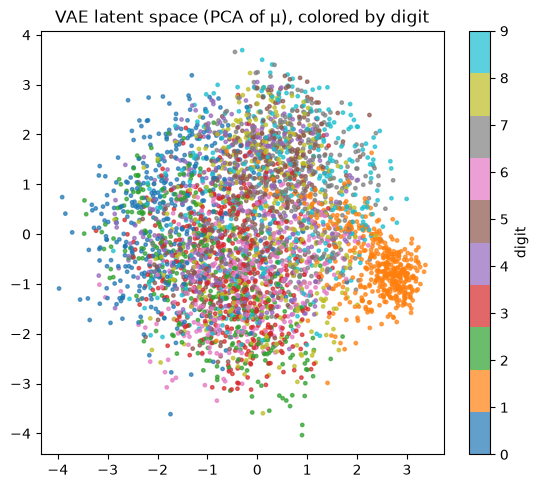

In [11]:
# A cheap, optional visualization not in the book: project the latent means (mu) for a batch of
# real digits down to 2D with PCA, colored by digit label, to make "densely and smoothly
# populated" concrete rather than just asserted.
from sklearn.decomposition import PCA

vae_model.eval()
mus, labels = [], []
with torch.no_grad():
    for images, lbls in mnist_loader:
        x = images.view(images.size(0), -1).to(DEVICE)
        mu, _ = vae_model.encode(x)
        mus.append(mu.cpu())
        labels.append(lbls)
        if sum(m.size(0) for m in mus) >= 4000:
            break

mus = torch.cat(mus).numpy()
labels = torch.cat(labels).numpy()
mus_2d = PCA(n_components=2, random_state=SEED).fit_transform(mus)

plt.figure(figsize=(6.5, 5.5))
sc = plt.scatter(mus_2d[:, 0], mus_2d[:, 1], c=labels, cmap="tab10", s=6, alpha=0.7)
plt.colorbar(sc, label="digit", ticks=range(10))
plt.title("VAE latent space (PCA of \u03bc), colored by digit")
plt.show()

---
## Part 3 — The forward process and noise schedules (§10.2.1, §10.2.3)

Before Recipe 10-1, the chapter derives the closed-form shortcut
$\mathbf{x}_t = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon$
and the linear/cosine noise schedules of §10.2.3. Here's both made visible: progressive
corruption of a real image at several noise levels, and the two schedules' $\bar\alpha_t$ curves
side by side.

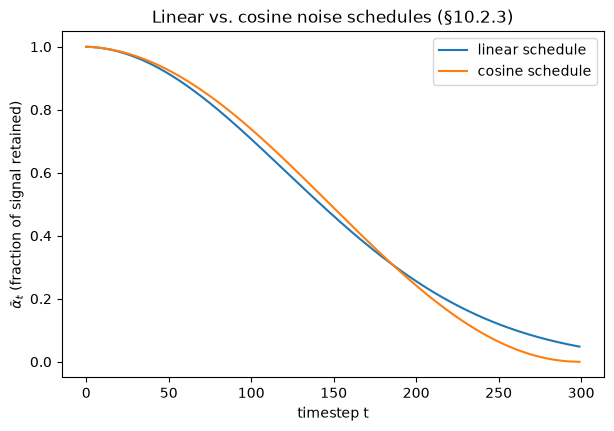

In [12]:
def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def cosine_schedule(T, s=0.008):
    """Nichol & Dhariwal 2021. Defines alpha_bar_t directly via a cosine curve,
    then backs out the per-step betas from it."""
    steps = torch.arange(T + 1, dtype=torch.float64)
    f_t = torch.cos(((steps / T) + s) / (1 + s) * math.pi / 2) ** 2
    alpha_bars = f_t / f_t[0]
    betas = 1 - (alpha_bars[1:] / alpha_bars[:-1])
    # 0.999, not 0.9999: Nichol & Dhariwal cap beta below 1 to avoid a singularity at t=T,
    # where alpha_t -> 0 makes the 1/sqrt(alpha_t) factor in ancestral sampling explode.
    return torch.clip(betas, 0.0001, 0.999)

T_demo = 300
lin_betas = linear_schedule(T_demo)
lin_abar = torch.cumprod(1.0 - lin_betas, dim=0)
cos_betas = cosine_schedule(T_demo).float()
cos_abar = torch.cumprod(1.0 - cos_betas, dim=0)

plt.figure(figsize=(7, 4.5))
plt.plot(lin_abar, label="linear schedule")
plt.plot(cos_abar, label="cosine schedule")
plt.xlabel("timestep t")
plt.ylabel(r"$\bar\alpha_t$ (fraction of signal retained)")
plt.title("Linear vs. cosine noise schedules (§10.2.3)")
plt.legend()
plt.show()

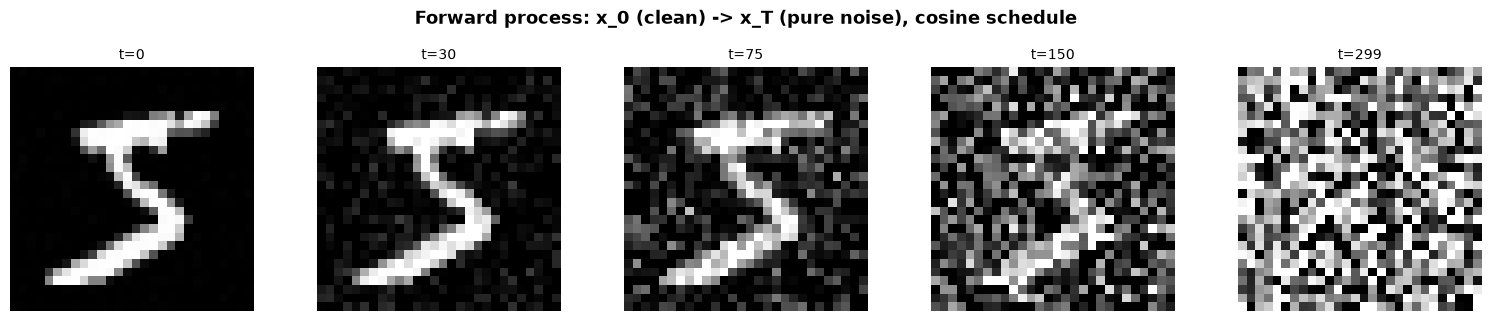

In [13]:
# Progressive corruption of one real MNIST digit, using the closed-form shortcut directly --
# no sequential simulation, exactly as §10.2.1 derives.
set_seed()
x0_img, _ = mnist_train[0]
x0_img = x0_img.view(-1).to(DEVICE) * 2 - 1  # scale to [-1, 1], matching the rest of the chapter

show_steps = [0, 30, 75, 150, 299]
noised = []
for t_step in show_steps:
    a_bar = cos_abar[t_step].to(DEVICE)
    eps = torch.randn_like(x0_img)
    x_t = a_bar.sqrt() * x0_img + (1 - a_bar).sqrt() * eps
    noised.append(((x_t.view(28, 28).cpu().numpy() + 1) / 2).clip(0, 1))

show_image_grid(noised, titles=[f"t={t}" for t in show_steps], cols=5,
                 suptitle="Forward process: x_0 (clean) -> x_T (pure noise), cosine schedule")

---
## Part 4 — Recipe 10-1: Diffusion on 2D points (§10.2.2)

This is the chapter's recipe almost verbatim — a tiny 3-layer MLP learns to denoise 2D points
from the "two moons" dataset (the same one Part 1's GAN trained on). Watching the reverse process
turn pure noise back into two crescents is, per §10.2.2, one of the fastest ways to build
intuition for what every later recipe in this chapter is doing at much larger scale.

In [14]:
set_seed()

X, _ = make_moons(n_samples=4000, noise=0.05)
X = torch.tensor(X, dtype=torch.float32)
X = (X - X.mean(0)) / X.std(0)          # normalize, same spirit as scaling pixels to [-1, 1]

# --- Fixed noise schedule (linear, T=100 -- small T is plenty for 2D) ---
T = 100
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)      # this is \bar{alpha}_t for t = 1..T

def forward_noise(x0, t, noise=None):
    """x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * eps -- the closed-form
    equation from §10.2.1, no sequential simulation needed."""
    if noise is None:
        noise = torch.randn_like(x0)
    a_bar = alpha_bars[t].unsqueeze(-1)                 # shape (batch, 1) for broadcasting
    x_t = a_bar.sqrt() * x0 + (1 - a_bar).sqrt() * noise
    return x_t, noise

class TinyDenoiser(nn.Module):
    def __init__(self, dim=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, dim),
        )

    def forward(self, x_t, t):
        t_feat = (t.float() / T).unsqueeze(-1)
        return self.net(torch.cat([x_t, t_feat], dim=-1))

model_2d = TinyDenoiser()
opt = torch.optim.Adam(model_2d.parameters(), lr=1e-3)

In [15]:
t0 = time.time()
N_2D_EPOCHS = 2000  # matches the book -- this recipe is cheap even at full scale
for epoch in range(N_2D_EPOCHS):
    t = torch.randint(0, T, (X.size(0),))
    x_t, noise = forward_noise(X, t)
    noise_pred = model_2d(x_t, t)
    loss = ((noise - noise_pred) ** 2).mean()      # this line IS the entire training objective

    opt.zero_grad()
    loss.backward()
    opt.step()

print(f"Trained {N_2D_EPOCHS} epochs in {time.time() - t0:.1f}s -- final loss {loss.item():.4f}")

Trained 2000 epochs in 4.4s -- final loss 0.5980


In [16]:
@torch.no_grad()
def sample_2d(n_points, record_steps=None):
    x_t = torch.randn(n_points, 2)                 # x_T ~ N(0, I): pure noise
    trajectory = {}
    for t_step in reversed(range(T)):
        t = torch.full((n_points,), t_step, dtype=torch.long)
        eps_pred = model_2d(x_t, t)
        alpha_t, a_bar_t = alphas[t_step], alpha_bars[t_step]

        # Ancestral update rule -- derived properly in §10.2.4; used here as-is.
        mean = (1 / alpha_t.sqrt()) * (x_t - (1 - alpha_t) / (1 - a_bar_t).sqrt() * eps_pred)
        if t_step > 0:
            noise = torch.randn_like(x_t)
            x_t = mean + betas[t_step].sqrt() * noise
        else:
            x_t = mean                              # no noise on the very last step

        if record_steps is not None and t_step in record_steps:
            trajectory[t_step] = x_t.clone()
    return x_t, trajectory

set_seed()
record_at = {99, 70, 40, 10, 0}
samples, trajectory = sample_2d(1000, record_steps=record_at)

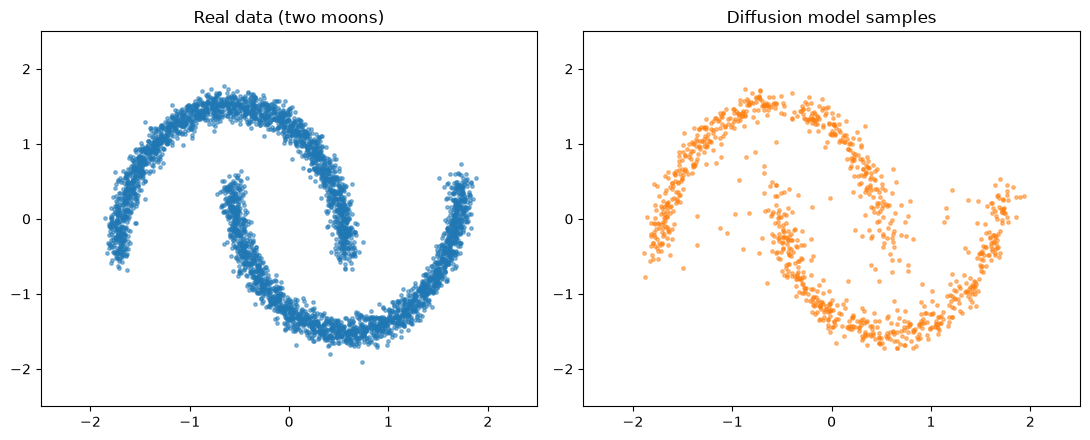

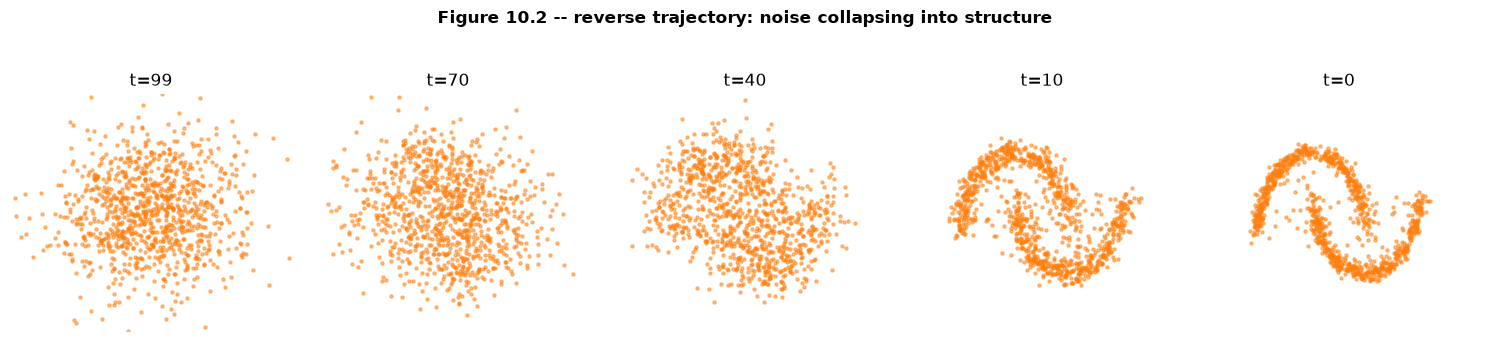

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X[:, 0], X[:, 1], s=6, alpha=0.5)
axes[0].set_title("Real data (two moons)")
axes[1].scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.5, color="C1")
axes[1].set_title("Diffusion model samples")
for ax in axes:
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()

# Figure 10.2 -- the reverse trajectory: watch structure emerge from noise.
steps_sorted = sorted(record_at, reverse=True)
fig, axes = plt.subplots(1, len(steps_sorted), figsize=(3 * len(steps_sorted), 3.2))
for ax, t_step in zip(axes, steps_sorted):
    pts = trajectory[t_step]
    ax.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.5, color="C1")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_title(f"t={t_step}")
    ax.axis("off")
fig.suptitle("Figure 10.2 -- reverse trajectory: noise collapsing into structure", y=1.05, fontweight="bold")
plt.tight_layout()
plt.show()

**Compare this to Part 1's GAN loss curves:** re-run the training cell above with a different
seed and look at how consistent the final loss is, run to run -- this is §10.2.4's "training a
diffusion model is regression" claim made concrete: an ordinary MSE loss on noise, no adversarial
game, no equilibrium to hope for.

---
## Part 5 — Recipe 10-2: A tiny image DDPM (§10.2.6)

Everything from Part 4 transfers to real images with two changes: the data is now a `(C, H, W)`
tensor, and the denoiser is a small U-Net (`TinyUNet`) instead of an MLP. Everything else --
`forward_noise`, the training loop, the loss, the sampling loop -- is unchanged.

**Reduced from the book:** the chapter trains for 20 epochs on the full 60,000-image
Fashion-MNIST training set (15-30 minutes on a GPU). This notebook trains for **5 epochs** by
default, which already produces rough garment-shaped blobs in a couple of minutes on a
Colab GPU. Raise `N_IMG_EPOCHS` below if you have the time.

In [18]:
from torch.utils.data import DataLoader
from torchvision.datasets import FashionMNIST

set_seed()

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
img_dataset = FashionMNIST(root="./data", train=True, download=True, transform=transform)
img_loader = DataLoader(img_dataset, batch_size=128, shuffle=True)
print(f"Fashion-MNIST: {len(img_dataset)} training images")

# --- Same schedule utilities as Part 4, now with the cosine option from §10.2.3 ---
T_img = 300
img_betas = cosine_schedule(T_img).float().to(DEVICE)   # on DEVICE: t is created there too
img_alphas = 1.0 - img_betas
img_alpha_bars = torch.cumprod(img_alphas, dim=0)

def forward_noise_img(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    a_bar = img_alpha_bars[t].view(-1, 1, 1, 1)         # broadcast over (C, H, W)
    return a_bar.sqrt() * x0 + (1 - a_bar).sqrt() * noise, noise

class SinusoidalTimeEmbedding(nn.Module):
    """A placeholder for now -- fully explained in §10.3, reused unchanged in §10.4's
    Stable Diffusion U-Net."""
    def __init__(self, dim=64):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t.float().unsqueeze(-1) * freqs.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=-1)

class TinyUNet(nn.Module):
    """Minimal encoder-decoder-with-skips denoiser -- a black box for this recipe.
    §10.3 dissects every piece of a production-shaped version of this class."""
    def __init__(self, channels=1, base=32, time_dim=64):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)
        self.time_proj = nn.Linear(time_dim, base * 2)

        self.down1 = nn.Conv2d(channels, base, 3, padding=1)
        self.down2 = nn.Conv2d(base, base * 2, 3, stride=2, padding=1)     # 28x28 -> 14x14
        self.bottleneck = nn.Conv2d(base * 2, base * 2, 3, padding=1)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 4, stride=2, padding=1)  # 14x14 -> 28x28
        self.out = nn.Conv2d(base * 2, channels, 3, padding=1)             # base*2: skip concat
        self.act = nn.ReLU()

    def forward(self, x, t):
        t_emb = self.time_proj(self.time_embed(t))[:, :, None, None]      # (B, base*2, 1, 1)

        skip = self.act(self.down1(x))                  # (B, base, 28, 28)
        h = self.act(self.down2(skip))                  # (B, base*2, 14, 14)
        h = self.act(self.bottleneck(h) + t_emb)         # inject timestep info here
        h = self.act(self.up1(h))                        # (B, base, 28, 28)
        h = torch.cat([h, skip], dim=1)                  # skip connection -- see §10.3
        return self.out(h)

img_model = TinyUNet().to(DEVICE)
img_opt = torch.optim.Adam(img_model.parameters(), lr=2e-4)

100%|██████████| 26.4M/26.4M [00:06<00:00, 3.95MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Fashion-MNIST: 60000 training images


In [19]:
N_IMG_EPOCHS = 5   # book default: 20, on the full dataset -- raise this if you have time/GPU

t0 = time.time()
for epoch in range(N_IMG_EPOCHS):
    for images, _ in img_loader:
        images = images.to(DEVICE)
        t = torch.randint(0, T_img, (images.size(0),), device=DEVICE)
        x_t, noise = forward_noise_img(images, t)
        noise_pred = img_model(x_t, t)
        loss = ((noise - noise_pred) ** 2).mean()

        img_opt.zero_grad()
        loss.backward()
        img_opt.step()

    print(f"epoch {epoch}: loss {loss.item():.4f}  elapsed {time.time() - t0:.1f}s")

epoch 0: loss 0.1524  elapsed 5.8s
epoch 1: loss 0.1528  elapsed 11.1s
epoch 2: loss 0.1498  elapsed 16.5s
epoch 3: loss 0.1713  elapsed 21.8s
epoch 4: loss 0.1493  elapsed 27.0s


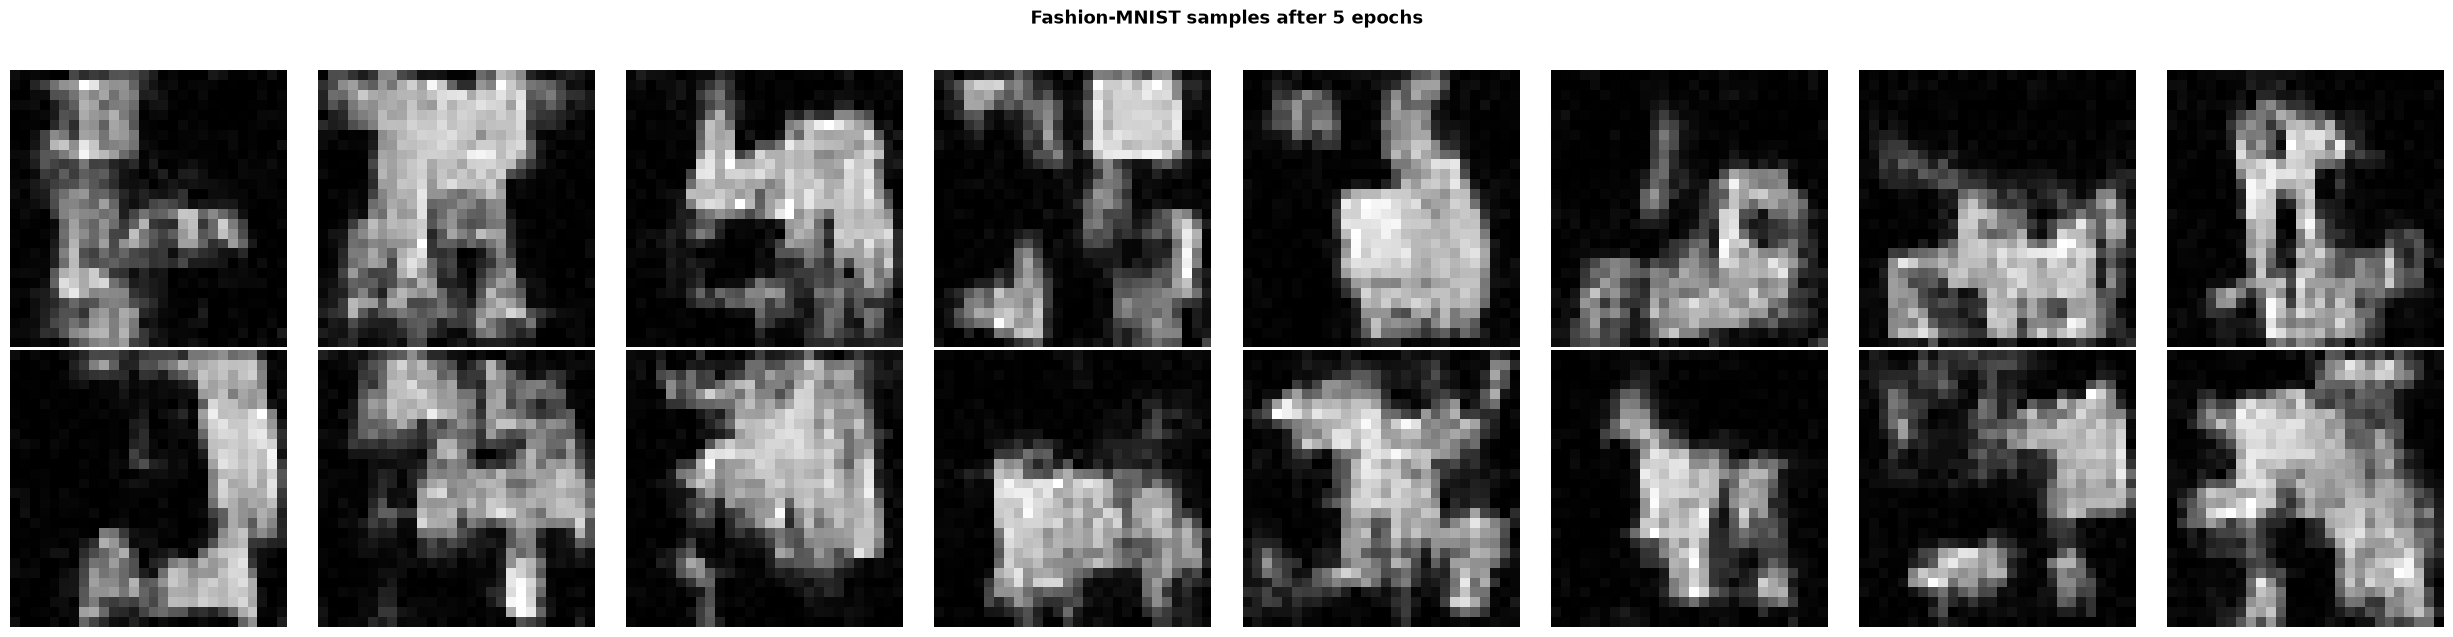

In [20]:
@torch.no_grad()
def sample_img(n_images, record_steps=None):
    x_t = torch.randn(n_images, 1, 28, 28, device=DEVICE)
    trajectory = {}
    for t_step in reversed(range(T_img)):
        t = torch.full((n_images,), t_step, dtype=torch.long, device=DEVICE)
        eps_pred = img_model(x_t, t)
        alpha_t, a_bar_t = img_alphas[t_step], img_alpha_bars[t_step]
        # Same ancestral step as Part 4, but routed through the x_0 estimate of §10.2.5 and
        # clipped to the data range. Algebraically identical; numerically far better behaved,
        # because the cosine schedule drives alpha_t very small near t=T.
        x0_pred = ((x_t - (1 - a_bar_t).sqrt() * eps_pred) / a_bar_t.sqrt()).clamp(-1, 1)
        a_bar_prev = img_alpha_bars[t_step - 1] if t_step > 0 else torch.ones_like(a_bar_t)
        mean = (a_bar_prev.sqrt() * img_betas[t_step] / (1 - a_bar_t)) * x0_pred                + (alpha_t.sqrt() * (1 - a_bar_prev) / (1 - a_bar_t)) * x_t
        if t_step > 0:
            noise = torch.randn_like(x_t)
            x_t = mean + img_betas[t_step].sqrt() * noise
        else:
            x_t = mean
        if record_steps is not None and t_step in record_steps:
            trajectory[t_step] = x_t.clone()
    return x_t, trajectory

set_seed()
img_samples, img_trajectory = sample_img(16, record_steps={299, 200, 100, 30, 0})
imgs_01 = [(s.squeeze(0).cpu().numpy() + 1) / 2 for s in img_samples.clamp(-1, 1)]
show_image_grid(imgs_01, cols=8, suptitle=f"Fashion-MNIST samples after {N_IMG_EPOCHS} epochs")

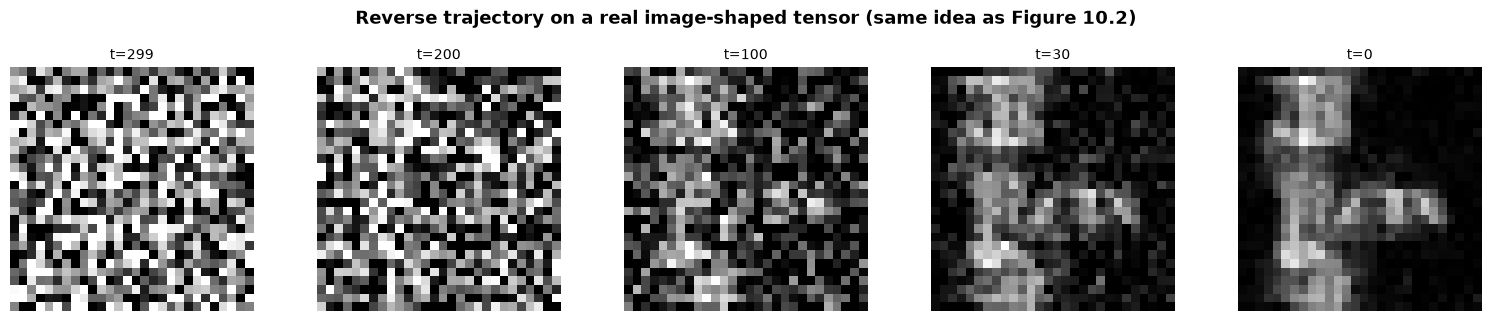

In [21]:
steps_sorted = sorted(img_trajectory, reverse=True)
one_trajectory = [((img_trajectory[t][0, 0].clamp(-1, 1).cpu().numpy() + 1) / 2) for t in steps_sorted]
show_image_grid(one_trajectory, titles=[f"t={t}" for t in steps_sorted], cols=len(steps_sorted),
                 suptitle="Reverse trajectory on a real image-shaped tensor (same idea as Figure 10.2)")

---
## Part 6 — Inside the denoiser: `DDPMUNet` (§10.3)

`TinyUNet` above works, but it's deliberately bare (one down/up level, no residual connections,
no attention). This is the real thing: skip connections, FiLM timestep conditioning, self- and
cross-attention at the bottleneck -- built exactly as the chapter walks through it, piece by
piece. Training this from scratch takes meaningfully longer than `TinyUNet`, so by default we
just verify it's wired correctly with a forward-pass shape check; there's an optional slower cell
below if you want to actually train it.

In [22]:
class ResidualBlock(nn.Module):
    """Two conv layers with a residual connection, modulated by the timestep embedding
    via FiLM (§10.3.2). This -- not a plain conv stack -- is the actual repeating unit
    inside a real DDPM U-Net; TinyUNet above skipped this purely for readability."""

    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_ch * 2)        # predicts (scale, shift)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        # FiLM conditioning: broadcast the timestep's influence over every spatial
        # position of this feature map, uniformly across (H, W).
        scale, shift = self.time_proj(t_emb).chunk(2, dim=-1)
        h = h * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SelfAttentionBlock(nn.Module):
    """Full spatial self-attention -- every pixel attends to every other pixel. Cost is
    O((H*W)^2), so (§10.3.3) this is only used at the lowest resolution."""

    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.mha = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).view(B, C, H * W).transpose(1, 2)      # (B, HW, C): one token/pixel
        h, _ = self.mha(h, h, h)                                 # Q = K = V = h
        h = h.transpose(1, 2).view(B, C, H, W)
        return x + h


class CrossAttentionBlock(nn.Module):
    """Same mechanism as SelfAttentionBlock (§10.3.4), but keys/values come from an
    external conditioning sequence (e.g. CLIP text tokens, §10.4) instead of the
    image's own features. A no-op until a real `context` is supplied."""

    def __init__(self, channels, context_dim=None, num_heads=4):
        super().__init__()
        context_dim = context_dim or channels
        self.norm = nn.GroupNorm(8, channels)
        self.to_kv = nn.Linear(context_dim, channels * 2)
        self.mha = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x, context=None):
        if context is None:
            return x                                             # not wired up until §10.4
        B, C, H, W = x.shape
        h = self.norm(x).view(B, C, H * W).transpose(1, 2)       # queries: (B, HW, C)
        k, v = self.to_kv(context).chunk(2, dim=-1)               # keys/values: (B, N_ctx, C)
        h, _ = self.mha(h, k, v)
        h = h.transpose(1, 2).view(B, C, H, W)
        return x + h


class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv2d(ch, ch, 3, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class DDPMUNet(nn.Module):
    """A production-shaped diffusion U-Net: 3 resolution levels (28 -> 14 -> 7),
    FiLM-conditioned residual blocks at every level (§10.3.2), self-attention at the
    7x7 bottleneck (§10.3.3), and a cross-attention hook at the same resolution ready
    for §10.4's text conditioning (§10.3.4). Drop-in upgrade for TinyUNet above --
    identical training loop, forward_noise(), and loss."""

    def __init__(self, channels=1, base=32, time_dim=128, context_dim=None):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)

        # Encoder: 28x28 (base) -> 14x14 (base*2) -> 7x7 (base*4)
        self.in_conv = nn.Conv2d(channels, base, 3, padding=1)
        self.down1 = ResidualBlock(base, base, time_dim)
        self.pool1 = Downsample(base)
        self.down2 = ResidualBlock(base, base * 2, time_dim)
        self.pool2 = Downsample(base * 2)

        # Bottleneck at 7x7 -- where global attention becomes affordable (§10.3.3)
        self.bottleneck1 = ResidualBlock(base * 2, base * 4, time_dim)
        self.self_attn = SelfAttentionBlock(base * 4)
        self.cross_attn = CrossAttentionBlock(base * 4, context_dim)
        self.bottleneck2 = ResidualBlock(base * 4, base * 4, time_dim)

        # Decoder: mirrors the encoder, consuming a skip connection at every level (§10.3.1)
        self.unpool2 = Upsample(base * 4)
        self.up2 = ResidualBlock(base * 4 + base * 2, base * 2, time_dim)   # + skip from down2
        self.unpool1 = Upsample(base * 2)
        self.up1 = ResidualBlock(base * 2 + base, base, time_dim)          # + skip from down1

        self.out_norm = nn.GroupNorm(8, base)
        self.out_conv = nn.Conv2d(base, channels, 3, padding=1)

    def forward(self, x, t, context=None):
        t_emb = self.time_embed(t)

        h0 = self.in_conv(x)                  # (B, base,   28, 28)
        h1 = self.down1(h0, t_emb)             # (B, base,   28, 28)  <- cached: skip 1
        h2 = self.pool1(h1)                    # (B, base,   14, 14)
        h2 = self.down2(h2, t_emb)             # (B, base*2, 14, 14)  <- cached: skip 2
        h3 = self.pool2(h2)                    # (B, base*2, 7,  7)

        h3 = self.bottleneck1(h3, t_emb)       # (B, base*4, 7, 7)
        h3 = self.self_attn(h3)                # global spatial context, cheap at 7x7
        h3 = self.cross_attn(h3, context)      # no-op unless a text context is supplied
        h3 = self.bottleneck2(h3, t_emb)       # (B, base*4, 7, 7)

        u2 = self.unpool2(h3)                                     # (B, base*4, 14, 14)
        u2 = self.up2(torch.cat([u2, h2], dim=1), t_emb)          # + skip 2 -> (B, base*2, 14, 14)
        u1 = self.unpool1(u2)                                     # (B, base*2, 28, 28)
        u1 = self.up1(torch.cat([u1, h1], dim=1), t_emb)          # + skip 1 -> (B, base,   28, 28)

        return self.out_conv(F.silu(self.out_norm(u1)))

In [23]:
# Shape check: does the architecture actually wire together correctly end to end?
ddpm_unet = DDPMUNet(channels=1, base=32, time_dim=128).to(DEVICE)
dummy_x = torch.randn(4, 1, 28, 28, device=DEVICE)
dummy_t = torch.randint(0, T_img, (4,), device=DEVICE)

with torch.no_grad():
    dummy_out = ddpm_unet(dummy_x, dummy_t)

n_params = sum(p.numel() for p in ddpm_unet.parameters())
print(f"input:  {tuple(dummy_x.shape)}")
print(f"output: {tuple(dummy_out.shape)}  (should match input)")
print(f"parameters: {n_params:,}  (vs. TinyUNet's {sum(p.numel() for p in img_model.parameters()):,})")
assert dummy_out.shape == dummy_x.shape
print("DDPMUNet is wired correctly.")

input:  (4, 1, 28, 28)
output: (4, 1, 28, 28)  (should match input)
parameters: 1,458,849  (vs. TinyUNet's 93,281)
DDPMUNet is wired correctly.


**Optional, slower:** train `DDPMUNet` the same way as Part 5's `TinyUNet` and compare sample
sharpness. This roughly doubles Part 5's training time for the same number of epochs, so it's
left commented out by default.

```python
# ddpm_unet_opt = torch.optim.Adam(ddpm_unet.parameters(), lr=2e-4)
# for epoch in range(N_IMG_EPOCHS):
#     for images, _ in img_loader:
#         images = images.to(DEVICE)
#         t = torch.randint(0, T_img, (images.size(0),), device=DEVICE)
#         x_t, noise = forward_noise_img(images, t)
#         noise_pred = ddpm_unet(x_t, t)          # context=None -> cross-attn stays a no-op
#         loss = ((noise - noise_pred) ** 2).mean()
#         ddpm_unet_opt.zero_grad(); loss.backward(); ddpm_unet_opt.step()
#     print(f"epoch {epoch}: loss {loss.item():.4f}")
```

---
## Part 7 — Latent Diffusion: Stable Diffusion with the hood open (§10.4)

**From here on, a GPU makes a big difference.** If you haven't already, go to
**Runtime → Change runtime type → T4 GPU**, then **Runtime → Restart session** and run all cells
again from the top.

§10.4.1's motivating numbers, made concrete:

In [24]:
pixel_positions = 512 * 512
pixel_attn_cost = pixel_positions ** 2
latent_positions = 64 * 64
latent_attn_cost = latent_positions ** 2

print(f"Pixel-space (512x512):  {pixel_positions:,} spatial positions, "
      f"{pixel_attn_cost:,} attention token-pairs")
print(f"Latent-space (64x64x4): {latent_positions:,} spatial positions, "
      f"{latent_attn_cost:,} attention token-pairs")
print(f"Latent space is {pixel_positions / latent_positions:.0f}x fewer spatial positions, "
      f"{pixel_attn_cost / latent_attn_cost:,.0f}x cheaper attention.")

Pixel-space (512x512):  262,144 spatial positions, 68,719,476,736 attention token-pairs
Latent-space (64x64x4): 4,096 spatial positions, 16,777,216 attention token-pairs
Latent space is 64x fewer spatial positions, 4,096x cheaper attention.


**Loading the three pretrained components** (§10.4.2): a VAE, a CLIP text encoder, and a U-Net --
structurally the exact `DDPMUNet` from Part 6, just far deeper and pretrained at scale. This uses
[`stable-diffusion-v1-5/stable-diffusion-v1-5`](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5),
a public mirror of SD 1.5 that needs **no HuggingFace account or login token**. The first run
downloads ~4 GB and caches it for the rest of the session.

In [26]:
from transformers import CLIPTokenizer, CLIPTextModel
from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler, ControlNetModel

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"   # public mirror, no login required
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32
VARIANT = "fp16" if DEVICE == "cuda" else None
NUM_INFERENCE_STEPS = 30   # book default is 50; reduced here for faster Colab runs

print(f"Loading Stable Diffusion components on {DEVICE} ({DTYPE})... "
      f"first run downloads ~4GB and may take a few minutes.")

vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae",
                                     torch_dtype=DTYPE, variant=VARIANT).to(DEVICE).eval()
tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder",
                                              torch_dtype=DTYPE, variant=VARIANT).to(DEVICE).eval()
# This IS DDPMUNet from Part 6 -- same skip connections, FiLM timestep conditioning,
# self-attention, and cross-attention blocks, just far deeper and pretrained at scale.
unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet",
                                             torch_dtype=DTYPE, variant=VARIANT).to(DEVICE).eval()
scheduler = DDIMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")     # §10.2.5

print("Done.")

Loading Stable Diffusion components on cuda (torch.float16)... first run downloads ~4GB and may take a few minutes.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Done.


**Component 2, concretely** (§10.4.2): CLIP turns a prompt into a `(1, 77, 768)` sequence of
per-token embeddings -- one vector per word-piece, not a single pooled sentence vector, because
cross-attention needs a sequence of keys/values to attend over.

In [27]:
demo_tokens = tokenizer(["a photorealistic render of a red teapot"],
                         padding="max_length", max_length=tokenizer.model_max_length,
                         truncation=True, return_tensors="pt")
with torch.no_grad():
    demo_embeddings = text_encoder(demo_tokens.input_ids.to(DEVICE))[0]

print("Token ids shape:     ", tuple(demo_tokens.input_ids.shape))
print("Text embedding shape:", tuple(demo_embeddings.shape), " (batch, 77 tokens, 768-dim each)")

Token ids shape:      (1, 77)
Text embedding shape: (1, 77, 768)  (batch, 77 tokens, 768-dim each)


**The denoising loop itself** (Recipe 10-3): DDIM stepping (§10.2.5) plus classifier-free
guidance (§10.4.3), driven by hand -- no `StableDiffusionPipeline`. Wrapped in a function here
purely so Parts 8-10 can reuse it without repeating the same ~25 lines each time; the function
body is exactly the chapter's 5-step recipe, unchanged.

In [28]:
@torch.no_grad()
def encode_prompt(prompt, negative_prompt=""):
    """Step 2: encode the prompt AND an empty/negative prompt, for classifier-free
    guidance (§10.4.3)."""
    text_input = tokenizer([prompt], padding="max_length", max_length=tokenizer.model_max_length,
                            truncation=True, return_tensors="pt")
    text_embeddings = text_encoder(text_input.input_ids.to(DEVICE))[0]

    uncond_input = tokenizer([negative_prompt], padding="max_length",
                              max_length=tokenizer.model_max_length,
                              truncation=True, return_tensors="pt")
    uncond_embeddings = text_encoder(uncond_input.input_ids.to(DEVICE))[0]

    # One batched forward pass through the U-Net handles both eps_uncond and eps_cond at once.
    return torch.cat([uncond_embeddings, text_embeddings])                     # (2, 77, 768)


def decode_latents(latents):
    """Step 5: decode to pixels exactly once, at the very end (§10.4.1/§10.4.2)."""
    with torch.no_grad():
        image = vae.decode(latents / 0.18215).sample
    image = (image / 2 + 0.5).clamp(0, 1)                                # undo [-1, 1] scaling
    image = (image[0].permute(1, 2, 0).float().cpu().numpy() * 255).astype("uint8")
    return Image.fromarray(image)


def sd_generate(prompt, guidance_scale=7.5, num_inference_steps=NUM_INFERENCE_STEPS,
                 height=512, width=512, seed=SEED, negative_prompt="",
                 controlnet_cond=None, snapshot_steps=None):
    """Recipe 10-3 (and, with controlnet_cond set, Recipe 10-4) as a reusable function.
    Steps 1-5 below are exactly the chapter's breakdown."""
    set_seed(seed)

    # --- Step 2: text encoding ---
    context = encode_prompt(prompt, negative_prompt)

    # --- Step 3: initialize latent noise at 64x64x4 -- 1/8 resolution, §10.4.1 ---
    latents = torch.randn(1, 4, height // 8, width // 8, device=DEVICE, dtype=context.dtype)
    scheduler.set_timesteps(num_inference_steps)
    latents = latents * scheduler.init_noise_sigma

    snapshots = {}

    # --- Step 4: DDIM stepping (§10.2.5) + classifier-free guidance (§10.4.3) ---
    for i, t in enumerate(scheduler.timesteps):
        latent_input = torch.cat([latents] * 2)                        # duplicate: uncond + cond
        latent_input = scheduler.scale_model_input(latent_input, t)

        with torch.no_grad():
            if controlnet_cond is not None:
                # The one addition for Recipe 10-4 (§10.5.2): ControlNet's per-resolution
                # residuals, folded into the frozen U-Net's forward pass.
                down_residuals, mid_residual = controlnet(
                    latent_input, t, encoder_hidden_states=context,
                    controlnet_cond=controlnet_cond, return_dict=False,
                )
                noise_pred = unet(
                    latent_input, t, encoder_hidden_states=context,
                    down_block_additional_residuals=down_residuals,
                    mid_block_additional_residual=mid_residual,
                ).sample
            else:
                noise_pred = unet(latent_input, t, encoder_hidden_states=context).sample

        noise_uncond, noise_cond = noise_pred.chunk(2)
        noise_pred = noise_uncond + guidance_scale * (noise_cond - noise_uncond)   # §10.4.3 formula

        latents = scheduler.step(noise_pred, t, latents).prev_sample

        if snapshot_steps and i in snapshot_steps:
            snapshots[i] = decode_latents(latents)

    # --- Step 5: decode to pixels ---
    image = decode_latents(latents)
    return image, snapshots

Generated in 1.2s on cuda


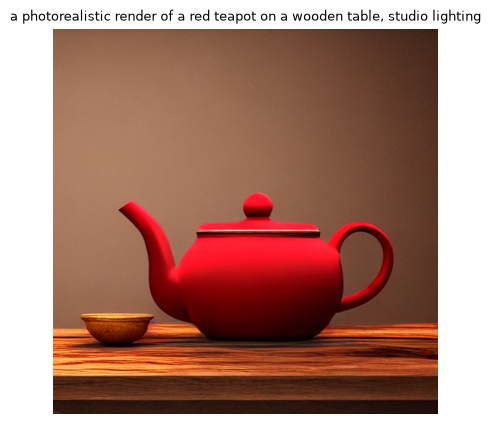

In [29]:
set_seed()
prompt = "a photorealistic render of a red teapot on a wooden table, studio lighting"
snap_at = {0, NUM_INFERENCE_STEPS // 3, 2 * NUM_INFERENCE_STEPS // 3, NUM_INFERENCE_STEPS - 1}

t0 = time.time()
image, snapshots = sd_generate(prompt, guidance_scale=7.5, snapshot_steps=snap_at)
print(f"Generated in {time.time() - t0:.1f}s on {DEVICE}")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(prompt, fontsize=9)
plt.show()

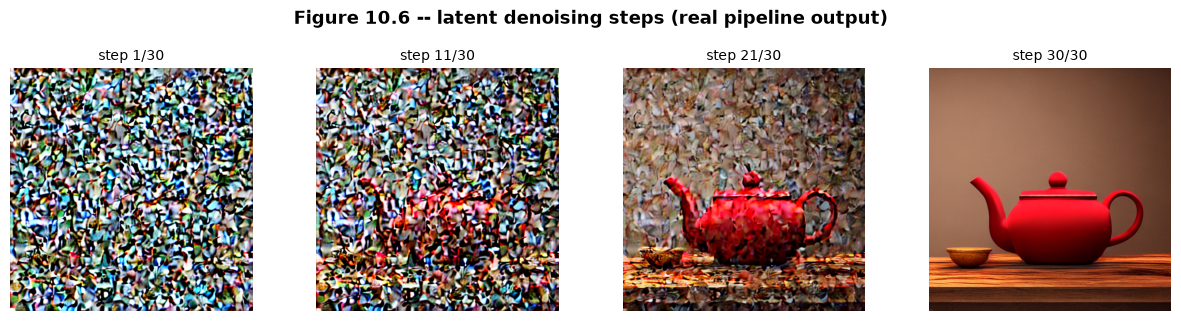

In [30]:
# Figure 10.6 -- real pipeline output, not a mockup: watch noise collapse into structure.
steps_sorted = sorted(snapshots)
show_image_grid([snapshots[s] for s in steps_sorted],
                 titles=[f"step {s + 1}/{NUM_INFERENCE_STEPS}" for s in steps_sorted],
                 cols=len(steps_sorted), cmap=None,
                 suptitle="Figure 10.6 -- latent denoising steps (real pipeline output)")

**One gap left before this is useful to a graphics engineer** (§10.4.4's closing point): a prompt
is semantic control, not spatial control. Part 9 (ControlNet) fixes that.

---
## Part 8 — Classifier-free guidance, in pictures (§10.5.1)

Same prompt, same starting noise, only `guidance_scale` changes. This is the real, generated
version of the chapter's Figure 10.7 sweep.

Generated 4 images in 3.5s


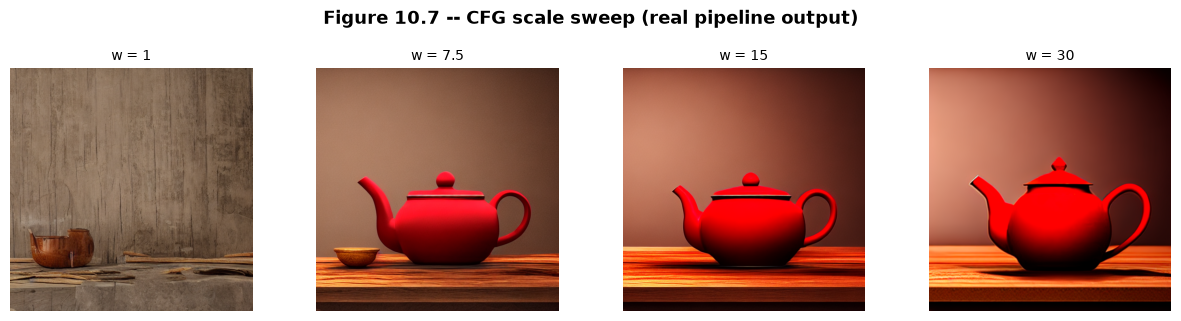

In [31]:
prompt = "a photorealistic render of a red teapot on a wooden table, studio lighting"
guidance_scales = [1, 7.5, 15, 30]

sweep_images = []
t0 = time.time()
for w in guidance_scales:
    img, _ = sd_generate(prompt, guidance_scale=w, seed=SEED)   # same seed every time -> same z_T
    sweep_images.append(img)
print(f"Generated {len(guidance_scales)} images in {time.time() - t0:.1f}s")

show_image_grid(sweep_images, titles=[f"w = {w}" for w in guidance_scales], cols=4, cmap=None,
                 suptitle="Figure 10.7 -- CFG scale sweep (real pipeline output)")

**What to look for:** `w=1` should look plausible but under-specified; `w=7.5` should track the
prompt clearly; by `w=30` expect oversaturated colors and visible artifacts -- §10.5.1's
description of walking past the region of latents the model actually knows how to decode cleanly.

---
## Part 9 — Recipe 10-4: ControlNet, the graphics engineer's payoff (§10.5.2-10.5.3)

The chapter's recipe conditions on a depth buffer rendered with Chapter 5's differentiable
renderer. This notebook has no 3D renderer dependency, so we generate a small **synthetic depth
buffer** instead -- an analytic teapot, honestly labeled as such. Swap `synthetic_teapot_depth()`
below for your own renderer's G-buffer output when you have one; nothing else in this cell needs
to change.

In [32]:
print("Loading ControlNet (depth) checkpoint...")
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-depth", torch_dtype=DTYPE
).to(DEVICE).eval()
print("Done.")

Loading ControlNet (depth) checkpoint...
Done.


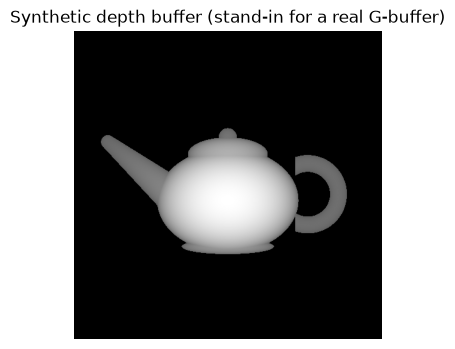

In [33]:
def _ellipsoid(X, Y, cx, cy, a, b, c):
    q = ((X - cx) / a) ** 2 + ((Y - cy) / b) ** 2
    return c * np.sqrt(np.clip(1.0 - q, 0.0, None))

def _tube(X, Y, p0, p1, r0, r1):
    """Round-section tube swept along p0->p1, radius tapering r0->r1."""
    p0, p1 = np.asarray(p0, float), np.asarray(p1, float)
    d = p1 - p0
    t = np.clip(((X - p0[0]) * d[0] + (Y - p0[1]) * d[1]) / float(d @ d), 0.0, 1.0)
    dist = np.hypot(X - (p0[0] + t * d[0]), Y - (p0[1] + t * d[1]))
    return np.sqrt(np.clip((r0 + t * (r1 - r0)) ** 2 - dist ** 2, 0.0, None))

def _torus(X, Y, cx, cy, R, r, keep):
    """Torus whose axis faces the viewer, so it reads as a ring; `keep` masks it to a C."""
    d = np.hypot(X - cx, Y - cy)
    return np.where(keep, np.sqrt(np.clip(r ** 2 - (d - R) ** 2, 0.0, None)), 0.0)

def synthetic_teapot_depth(resolution=512):
    """A minimal analytic stand-in for a rendered depth buffer -- near=bright / far=dark on a
    flat background -- shaped like the teapot the chapter's Recipe 10-4 asks for: an ellipsoid
    body, a lid and knob, a tapered spout and a half-torus handle. This is NOT an actual
    renderer's G-buffer. Swap it for Chapter 5's differentiable renderer output (or any
    depth/normal buffer of your own)."""
    lin = np.linspace(-1.0, 1.0, resolution)
    X, Y = np.meshgrid(lin, -lin)                                   # Y up
    parts = [
        _ellipsoid(X, Y, 0.00, -0.10, 0.46, 0.34, 0.42),            # body
        _ellipsoid(X, Y, 0.00,  0.20, 0.26, 0.11, 0.22),            # lid
        _ellipsoid(X, Y, 0.00,  0.31, 0.06, 0.06, 0.07),            # knob
        _tube(X, Y, (-0.38, -0.05), (-0.78, 0.28), 0.115, 0.045),   # spout
        _torus(X, Y, 0.52, -0.06, 0.20, 0.055, X > 0.44),           # handle
        _ellipsoid(X, Y, 0.00, -0.40, 0.30, 0.05, 0.16),            # foot
    ]
    z = np.max(np.stack(parts), axis=0)
    depth = np.zeros_like(z)
    inside = z > 0
    depth[inside] = 0.35 + 0.65 * (z[inside] / z.max())
    return depth.astype(np.float32)

depth_map = synthetic_teapot_depth(512)

depth_image = torch.from_numpy(depth_map).to(DEVICE, dtype=DTYPE)
depth_image = depth_image.unsqueeze(0).unsqueeze(0).repeat(2, 3, 1, 1)  # (2,3,512,512):
                                                                          # one copy per CFG branch
plt.figure(figsize=(4, 4))
plt.imshow(depth_map, cmap="gray")
plt.axis("off")
plt.title("Synthetic depth buffer (stand-in for a real G-buffer)")
plt.show()


Generated in 1.3s


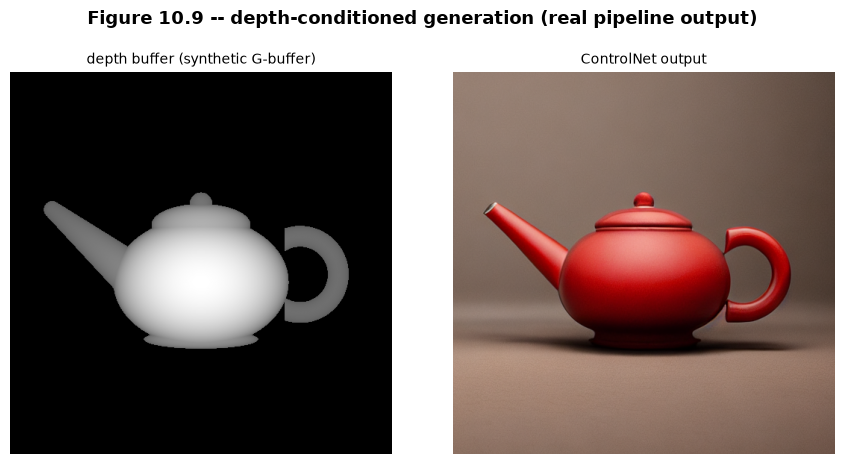

In [34]:
cn_prompt = "a photorealistic ceramic teapot, glossy red glaze, studio lighting"

t0 = time.time()
controlnet_image, _ = sd_generate(cn_prompt, guidance_scale=7.5, controlnet_cond=depth_image, seed=SEED)
print(f"Generated in {time.time() - t0:.1f}s")

show_image_grid([depth_map, controlnet_image], cmap="gray",
                 titles=["depth buffer (synthetic G-buffer)", "ControlNet output"], cols=2,
                 figsize=(9, 4.5),
                 suptitle="Figure 10.9 -- depth-conditioned generation (real pipeline output)")

**What to look for:** the generated object's silhouette and placement should match the depth
buffer's teapot almost exactly, while material, color, and lighting come entirely from the text
prompt -- exactly §10.5.2's "your renderer's own G-buffer becomes a creative input device," just
with a synthetic teapot standing in for a real render.

---
## Part 10 — Recipe 10-5: Seamless tileable textures (§10.6.1-10.6.2)

No retraining, no new weights -- just a structural edit to the already-pretrained model,
`make_circular()`, applied in place. We'll generate once before the swap and once after, with the
same seed and prompt, to make the before/after honest and directly comparable.

Swapped every Conv2d's padding_mode to 'circular' in unet and vae (in place).


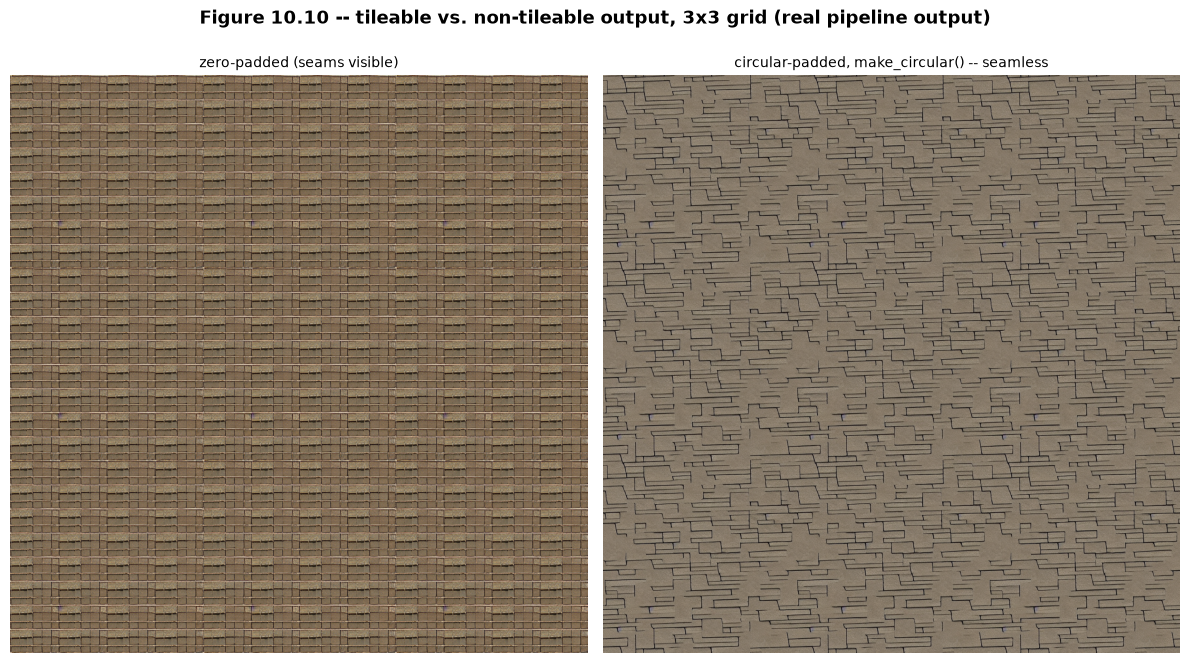

In [35]:
def make_circular(module: nn.Module) -> None:
    """Recursively swap every Conv2d's padding_mode to 'circular', in place. Applied to
    both the U-Net and the VAE (encoder + decoder) -- §10.6.1 explains why both need it."""
    for child in module.children():
        if isinstance(child, nn.Conv2d) and child.padding_mode != "circular":
            child.padding_mode = "circular"
        make_circular(child)


def tile3x3(img: Image.Image) -> Image.Image:
    w, h = img.size
    canvas = Image.new("RGB", (w * 3, h * 3))
    for i in range(3):
        for j in range(3):
            canvas.paste(img, (i * w, j * h))
    return canvas

tile_prompt = "seamless tileable stone brick texture, top-down, flat lighting"

set_seed()
img_before, _ = sd_generate(tile_prompt, guidance_scale=7.5, seed=SEED)

make_circular(unet)
make_circular(vae)
print("Swapped every Conv2d's padding_mode to 'circular' in unet and vae (in place).")

img_after, _ = sd_generate(tile_prompt, guidance_scale=7.5, seed=SEED)

show_image_grid([tile3x3(img_before), tile3x3(img_after)], cmap=None,
                 titles=["zero-padded (seams visible)", "circular-padded, make_circular() -- seamless"],
                 cols=2, figsize=(12, 6.5),
                 suptitle="Figure 10.10 -- tileable vs. non-tileable output, 3x3 grid (real pipeline output)")

**Note:** `unet` and `vae` are now permanently circular-padded for the rest of this session (that
mutation is the whole point of §10.6.1's trick). If you want to go back to ordinary generation
afterward, re-run the "Loading Stable Diffusion components" cell in Part 7 to get fresh copies.

---
## Closing: diffusion as an estimator, not a generator (§10.6.3)

Every recipe in this notebook ran the same direction: noise in, photorealistic image out.
**Marigold** (Ke et al., 2024) inverts this -- fine-tuning the same pretrained U-Net to denoise
*depth-map* latents conditioned on an RGB *image*, turning a text-to-image model into a depth
*estimator* whose generative visual prior outperforms depth regressors trained from scratch. No
new mechanism is needed to understand it: it's every piece built in this notebook, pointed at a
different target modality. That's the idea to carry forward: **a generative prior is an
inverse-rendering prior.**

### What to try next
- Swap `MODEL_ID` / `CONTROLNET_ID` for a different checkpoint (e.g. an SDXL or SD 2.1 variant)
  and see what changes.
- Replace `synthetic_teapot_depth()` in Part 9 with a depth map you rendered yourself, or even a
  photo run through a monocular depth model.
- Raise `N_IMG_EPOCHS` in Part 5, or train the full `DDPMUNet` from Part 6, for sharper
  Fashion-MNIST samples.
- Try your own prompts throughout Parts 7-10 -- everything here is a normal Python function you
  can call again with different arguments.